## SAM EVAL

In [ ]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import cv2
import numpy as np
import json
import os
from pycocotools import mask as maskUtils
import matplotlib.pyplot as plt
from sam2.data_utils.utils import calculate_mask_ap, sliding_window_inference

sam2_checkpoint = "sam2_logs/configs/sam2.1_iou_exp/iou0.6/sam2.1_hiera_l_OBIMD_stage4.yaml/checkpoints/checkpoint_5.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l_highres.yaml"

sam2_model = build_sam2(model_cfg, sam2_checkpoint, device='cuda:0')

predictor = SAM2ImagePredictor(sam2_model)

In [ ]:
miou = []
fscore = []
gt_coco_format = dict(info={}, license=[], categories=[dict(id=1, name="oracle")],
                      images=[], annotations=[])
pred_coco = []
for i, img_path in enumerate(sorted(os.listdir('data/OBIMD_test100/rubbing'))):
    image = cv2.imread(os.path.join('data/OBIMD_test100/rubbing', img_path))
    H, W = image.shape[:2]
    gt_masks = cv2.imread(os.path.join('data/OBIMD_test100/facsimile', img_path), cv2.IMREAD_GRAYSCALE) / 255
    base_name = os.path.splitext(img_path)[0]
    gt_coco_format['images'].append(dict(id=i, file_name=img_path, height=H, width=W))

    with open(os.path.join('data/OBIMD_test100/facsimile_json', f'{base_name}.json')) as f:
        data = json.load(f)
    predictor.set_image(image)

    # 使用 global prompt
    # global_mask, _, _ = predictor.predict(
    #     point_coords=None,
    #     point_labels=None,
    #     box=[0, 0, W, H],
    #     multimask_output=False,
    #     return_logits=True
    # )
    # global_mask = 255 - np.broadcast_to(global_mask.squeeze(0)[..., np.newaxis], (H, W, 3)).astype(np.uint8) * 255
    # result = detector(global_mask)[0]
    # input_box = result.boxes.xyxy.cpu().numpy().astype(int)

    # 输入yolo结果
    input_box = []
    with open(os.path.join('data/OBIMD_test100/yolo_prediction_x', img_path.replace('.jpg', '.txt'))) as f:
        for line in f:
            box = list(map(float, line.strip().split()[1:]))
            x,y,w,h = box
            x0, y0 = int((x - w/2) * W), int((y - h/2) * H)
            x1, y1 = int((x + w/2) * W), int((y + h/2) * H)
            input_box.append([x0, y0, x1, y1])
    input_box = np.array(input_box).reshape(-1, 4)
    
    # 输入ground truth
    # input_box = []
    # for d in data['annotations']:
    #     input_box.append(d['bbox'])
    # input_box = np.array(input_box).reshape(-1, 4)
    # input_box[:, 2:] += input_box[:, :2] # Convert from [x, y, w, h] to [x0, y0, x1, y1]

    # 加载ground truth
    for d in data['annotations']:
        binary_mask = maskUtils.decode(d['segmentation'])
        d.update({"image_id": i, "category_id": 1, "iscrowd": 0})
        d['bbox'] = d['bbox']
        gt_coco_format['annotations'].append(d)
    
    masks, scores, _ = predictor.predict(
        point_coords=None,
        point_labels=None,
        box=input_box,
        multimask_output=False,
    )
    if len(masks) == 1:
        masks = masks[None]
    masks = masks.astype(np.uint8) * 255

    # 统计instance segmentation指标
    for mask, score, box in zip(masks, scores, input_box):
        mask = np.asfortranarray(mask[0])
        rle = maskUtils.encode(mask)
        rle['counts'] = rle['counts'].decode('utf-8')
        area = maskUtils.area(rle)
        bbox = maskUtils.toBbox(rle)
        box[2:] = box[2:] - box[:2] # Convert from [x0, y0, x1, y1] to [x, y, w, h]
        crop_box = box.tolist()
        pred_coco.append(dict(image_id=i,
                              category_id=1,
                              bbox=bbox.astype(int).tolist(), 
                              area=int(area), 
                              segmentation=rle, 
                              score=float(score), 
                              crop_box=crop_box))
    
    # 计算语义分割指标    
    masks = masks.squeeze(1).any(axis=0)
    miou.append(np.sum(masks * gt_masks) / (np.sum(masks) + np.sum(gt_masks) - np.sum(masks * gt_masks)))
    precision = np.sum(masks * gt_masks) / np.sum(masks)
    recall = np.sum(masks * gt_masks) / np.sum(gt_masks)
    fscore.append(2 * precision * recall / (precision + recall))
print('miou', np.mean(miou), 'fscore', np.mean(fscore))
calculate_mask_ap(gt_coco_format, pred_coco)

In [ ]:
# 测试花东效果
miou = []
fscore = []
gt_coco_format = dict(info={}, license=[], categories=[dict(id=1, name="oracle")],
                      images=[], annotations=[])
pred_coco = []
with open("data/OBIMD_hd_test/test.txt") as f:
    test_files = [line.strip() for line in f]
for i, img_path in enumerate(test_files):
    img_path = img_path + '.jpg'
    image = cv2.imread(os.path.join('data/OBIMD_hd_test/rubbing', img_path))
    H, W = image.shape[:2]
    gt_masks = cv2.imread(os.path.join('data/OBIMD_hd_test/facsimile', img_path), cv2.IMREAD_GRAYSCALE) / 255
    base_name = os.path.splitext(img_path)[0]
    gt_coco_format['images'].append(dict(id=i, file_name=img_path, height=H, width=W))

    with open(os.path.join('data/OBIMD_hd_test/facsimile_json', f'{base_name}.json')) as f:
        data = json.load(f)
    predictor.set_image(image)

    # # 输入yolo结果
    # input_box = []
    # with open(os.path.join('data/OBIMD_hd_test/yolo_prediction', img_path.replace('.jpg', '.txt'))) as f:
    #     for line in f:
    #         box = list(map(float, line.strip().split()[1:]))
    #         x,y,w,h = box
    #         x0, y0 = int((x - w/2) * W), int((y - h/2) * H)
    #         x1, y1 = int((x + w/2) * W), int((y + h/2) * H)
    #         input_box.append([x0, y0, x1, y1])
    # input_box = np.array(input_box).reshape(-1, 4)
    
    # 输入ground truth
    input_box = []
    for d in data['annotations']:
        input_box.append(d['bbox'])
    input_box = np.array(input_box).reshape(-1, 4)
    input_box[:, 2:] += input_box[:, :2] # Convert from [x, y, w, h] to [x0, y0, x1, y1]

    # 加载ground truth
    for d in data['annotations']:
        binary_mask = maskUtils.decode(d['segmentation'])
        d.update({"image_id": i, "category_id": 1, "iscrowd": 0})
        d['bbox'] = d['bbox']
        gt_coco_format['annotations'].append(d)
    
    masks, scores, _ = predictor.predict(
        point_coords=None,
        point_labels=None,
        box=input_box,
        multimask_output=False,
    )
    if len(masks) == 1:
        masks = masks[None]
    masks = masks.astype(np.uint8) * 255

    # 统计instance segmentation指标
    for mask, score, box in zip(masks, scores, input_box):
        mask = np.asfortranarray(mask[0])
        rle = maskUtils.encode(mask)
        rle['counts'] = rle['counts'].decode('utf-8')
        area = maskUtils.area(rle)
        bbox = maskUtils.toBbox(rle)
        box[2:] = box[2:] - box[:2] # Convert from [x0, y0, x1, y1] to [x, y, w, h]
        crop_box = box.tolist()
        pred_coco.append(dict(image_id=i,
                              category_id=1,
                              bbox=bbox.astype(int).tolist(), 
                              area=int(area), 
                              segmentation=rle, 
                              score=float(score), 
                              crop_box=crop_box))
    
    # 计算语义分割指标    
    masks = masks.squeeze(1).any(axis=0)
    miou.append(np.sum(masks * gt_masks) / (np.sum(masks) + np.sum(gt_masks) - np.sum(masks * gt_masks)))
    precision = np.sum(masks * gt_masks) / np.sum(masks)
    recall = np.sum(masks * gt_masks) / np.sum(gt_masks)
    fscore.append(2 * precision * recall / (precision + recall))
print('miou', np.mean(miou), 'fscore', np.mean(fscore))
calculate_mask_ap(gt_coco_format, pred_coco)

## 滑动窗口

In [ ]:
miou = []
fscore = []
gt_coco_format = dict(info={}, license=[], categories=[dict(id=1, name="oracle")],
                      images=[], annotations=[])
pred_coco = []
for i, img_path in enumerate(sorted(os.listdir('data/OBIMD_test100/JPEGImages'))):
    image = cv2.imread(os.path.join('data/OBIMD_test100/JPEGImages', img_path))
    H, W = image.shape[:2]
    gt_masks = cv2.imread(os.path.join('data/OBIMD_test100/VOC', img_path), cv2.IMREAD_GRAYSCALE) / 255
    base_name = os.path.splitext(img_path)[0]
    gt_coco_format['images'].append(dict(id=i, file_name=img_path, height=H, width=W))

    with open(os.path.join('data/OBIMD_test100/facsimile_json', f'{base_name}.json')) as f:
        data = json.load(f)
    predictor.set_image(image)

    # 输入yolo结果，逐张放缩区域
    masks = []
    scores = []
    with open(os.path.join('data/OBIMD_test100/yolo_prediction', img_path.replace('.jpg', '.txt'))) as f:
        for line in f:
            box = list(map(float, line.strip().split()[1:]))
            x,y,w,h = box
            w_ = max(w * 1.2 * W, 1024)
            h_ = max(h * 1.2 * H, 1024)
            x0, y0 = int((x - w/2) * W), int((y - h/2) * H)
            x1, y1 = int((x + w/2) * W), int((y + h/2) * H)
            x0_, y0_ = int(max(x * W - w_/2, 0)), int(max(y * H - h_/2, 0))
            x1_, y1_ = int(min(x * W + w_/2, W)), int(min(y * H + h_/2, H))
            crop_image = image[y0_:y1_, x0_:x1_]
            crop_box = np.array([x0-x0_, y0-y0_, x1-x0_, y1-y0_]).reshape(1, 1, 4)

            obj_mask = np.zeros((H, W), dtype=np.uint8)
            predictor.set_image(crop_image)
            mask, score, _ = predictor.predict(
                point_coords=None,
                point_labels=None,
                box=crop_box,
                multimask_output=False,
            )

            obj_mask[y0_:y1_, x0_:x1_] = mask[0].astype(np.uint8) * 255
            masks.append(obj_mask)
            scores.append(score)
    masks = np.stack(masks, axis=0)

    # 加载ground truth
    for d in data['annotations']:
        binary_mask = maskUtils.decode(d['segmentation'])
        d.update({"image_id": i, "category_id": 1, "iscrowd": 0})
        d['bbox'] = d['crop_box']
        gt_coco_format['annotations'].append(d)

    # 统计instance segmentation指标
    for mask, score in zip(masks, scores):
        mask = np.asfortranarray(mask)
        rle = maskUtils.encode(mask)
        rle['counts'] = rle['counts'].decode('utf-8')
        area = maskUtils.area(rle)
        bbox = maskUtils.toBbox(rle)
        pred_coco.append(dict(image_id=i,
                              category_id=1,
                              bbox=bbox.astype(int).tolist(), 
                              area=int(area), 
                              segmentation=rle, 
                              score=float(score)))
    
    # 计算语义分割指标    
    masks = masks.any(axis=0)
    miou.append(np.sum(masks * gt_masks) / (np.sum(masks) + np.sum(gt_masks) - np.sum(masks * gt_masks)))
    precision = np.sum(masks * gt_masks) / np.sum(masks)
    recall = np.sum(masks * gt_masks) / np.sum(gt_masks)
    fscore.append(2 * precision * recall / (precision + recall))
print('miou', np.mean(miou), 'fscore', np.mean(fscore))
calculate_mask_ap(gt_coco_format, pred_coco)

In [ ]:
miou = []
fscore = []
gt_coco_format = dict(info={}, license=[], categories=[dict(id=1, name="oracle")],
                      images=[], annotations=[])
pred_coco = []
for i, img_path in enumerate(sorted(os.listdir('data/OBIMD_test100/JPEGImages'))):
    image = cv2.imread(os.path.join('data/OBIMD_test100/JPEGImages', img_path))
    H, W = image.shape[:2]
    gt_masks = cv2.imread(os.path.join('data/OBIMD_test100/VOC', img_path), cv2.IMREAD_GRAYSCALE) / 255
    base_name = os.path.splitext(img_path)[0]
    gt_coco_format['images'].append(dict(id=i, file_name=img_path, height=H, width=W))

    with open(os.path.join('data/OBIMD_test100/facsimile_json', f'{base_name}.json')) as f:
        data = json.load(f)
    predictor.set_image(image)

    # # 输入yolo结果
    input_box = []
    with open(os.path.join('data/OBIMD_test100/yolo_prediction', img_path.replace('.jpg', '.txt'))) as f:
        for line in f:
            box = list(map(float, line.strip().split()[1:]))
            x,y,w,h = box
            x0, y0 = int((x - w/2) * W), int((y - h/2) * H)
            x1, y1 = int((x + w/2) * W), int((y + h/2) * H)
            input_box.append([x0, y0, x1, y1])
    input_box = np.array(input_box).reshape(-1, 4)

    # 加载ground truth
    for d in data['annotations']:
        binary_mask = maskUtils.decode(d['segmentation'])
        d.update({"image_id": i, "category_id": 1, "iscrowd": 0})
        d['bbox'] = d['crop_box']
        gt_coco_format['annotations'].append(d)
    
    masks, scores = sliding_window_inference(predictor, image, input_box)
    masks = masks.astype(np.uint8) * 255

    # 统计instance segmentation指标
    for mask, score, box in zip(masks, scores, input_box):
        mask = np.asfortranarray(mask[0])
        rle = maskUtils.encode(mask)
        rle['counts'] = rle['counts'].decode('utf-8')
        area = maskUtils.area(rle)
        bbox = maskUtils.toBbox(rle)
        box[2:] = box[2:] - box[:2] # Convert from [x0, y0, x1, y1] to [x, y, w, h]
        crop_box = box.tolist()
        pred_coco.append(dict(image_id=i,
                              category_id=1,
                              bbox=bbox.astype(int).tolist(), 
                              area=int(area), 
                              segmentation=rle, 
                              score=float(score), 
                              crop_box=crop_box))
    
    # 计算语义分割指标    
    masks = masks.squeeze(1).any(axis=0)
    miou.append(np.sum(masks * gt_masks) / (np.sum(masks) + np.sum(gt_masks) - np.sum(masks * gt_masks)))
    precision = np.sum(masks * gt_masks) / np.sum(masks)
    recall = np.sum(masks * gt_masks) / np.sum(gt_masks)
    fscore.append(2 * precision * recall / (precision + recall))
print('miou', np.mean(miou), 'fscore', np.mean(fscore))
calculate_mask_ap(gt_coco_format, pred_coco)

## 数据飞轮数据split

In [ ]:
import os
import re
difference = []
file = set([int(f.split('.')[0][1:]) for f in os.listdir('data/OBIMD_raw/OBIMD_rubbing') if f.startswith('h') and not f.startswith('hd')])
for unsuper_data in os.listdir("/data/huxingjian/historical_document/YQWY/HJ"):
    try:
        image_id = int(unsuper_data.split('.')[0][1:])
        if image_id not in file:
            difference.append(unsuper_data)
    except:
        # 可能是“合xxx正”这种
        image_id = int(re.findall(r'\d+', unsuper_data)[0])
        if image_id not in file:
            difference.append(unsuper_data)
        else:
            print(f"File {unsuper_data} exists in the dataset.")


## 数据处理

In [ ]:
# 过一遍iou的分布，看看大于0.5的有多少
import os
import json
import matplotlib.pyplot as plt
import numpy as np
ious = []

input_dir = 'data_YQWY/sam_mining_stage2/facsimile_json_x'
cnt = 0
# tgt_dir = 'data/OBIMD_stage2_nosheer/facsimile_json_iou0.6'
# os.makedirs(tgt_dir, exist_ok=False)
for file in os.listdir(input_dir):
    with open(os.path.join(input_dir, file)) as f:
        data = json.load(f)
    if len([annotation['predicted_iou'] for annotation in data['annotations'] if annotation['predicted_iou'] > 0.6]) > 0:
        cnt += 1
    ious.extend([annotation['predicted_iou'] for annotation in data['annotations']])
    # filter_annotions = dict(image_info=data['image_info'], annotations=[])
    # filter_annotions['annotations'] = [annotation for annotation in data['annotations'] if annotation['predicted_iou'] > 0.6]
    # if len(filter_annotions['annotations']) == 0:
    #     continue
    # with open(os.path.join(tgt_dir, file), 'w') as f:
    #     json.dump(filter_annotions, f, indent=2)
# with open("data/OBIMD_raw_hj/train.txt") as f:
#     train = set([l.strip() for l in f.readlines()])
# with open("data/OBIMD_stage2_highres/train_replace.txt", 'w') as f:
#     for file in os.listdir(tgt_dir):
#         if file.split('.')[0] in train:
#             f.write(file.split('.')[0] + '\n')
ious = np.array(ious)
plt.hist(ious), len(ious[ious>0.6]), len(ious)

In [ ]:
# 一阶段飞轮数据挑选
import os
import json
import matplotlib.pyplot as plt
import numpy as np
iou_threshold = 0.5
tgt_dir = f'data/OBIMD_iou{iou_threshold}/stage1/facsimile_json'
accept_dir = f'data/OBIMD_iou{iou_threshold}/coldstart/facsimile_json'
input_dir = f'data/OBIMD_iou{iou_threshold}/stage1/facsimile_json_replace'
train_text = f'data/OBIMD_iou{iou_threshold}/stage1/train.txt'

# os.makedirs(tgt_dir, exist_ok=False)
with open("data/OBIMD_raw_hj/train.txt") as f:
    train_list = [l.strip() for l in f.readlines()]
for file in train_list:
    file = file + '.json'
    annotations = []
    image_info = {}
    if os.path.exists(os.path.join(accept_dir, file)):
        with open(os.path.join(accept_dir, file)) as f:
            data = json.load(f)
        annotations.extend(data['annotations'])
        image_info = data['image_info']

    if os.path.exists(os.path.join(input_dir, file)):
        try:
            with open(os.path.join(input_dir, file)) as f:
                data = json.load(f)
        except:
            print(file)
            raise ValueError(f"Error loading {file} in {input_dir}")
        annotations.extend([annotation for annotation in data['annotations']]) # if annotation['predicted_iou'] > iou_threshold])
        image_info = data['image_info']
        
    filter_annotions = dict(image_info=image_info, annotations=annotations)
    if len(filter_annotions['annotations']) == 0:
        continue
    with open(os.path.join(tgt_dir, file), 'w') as f:
        json.dump(filter_annotions, f, indent=2)
with open("data/OBIMD_raw_hj/train.txt") as f:
    train = set([l.strip() for l in f.readlines()])
with open(train_text, 'w') as f:
    for file in os.listdir(tgt_dir):
        if file.split('.')[0] in train:
            f.write(file.split('.')[0] + '\n')

In [ ]:
# 二阶段飞轮数据挑选
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
tgt_dir = 'data_YQWY/sam_mining_stage2/facsimile_json_iou0.6_x'
input_dir = 'data_YQWY/sam_mining_stage2/facsimile_json_x'
accept_dir = 'data_YQWY/sam_mining_stage1/facsimile_json_iou0.6_x'

def area_ratio(annotation):
    bbox = annotation['bbox']
    area = bbox[2] * bbox[3]
    return annotation['area'] / area

os.makedirs(tgt_dir, exist_ok=True)
for file in tqdm(os.listdir(input_dir)):
    annotations_dict = {}
    image_info = {}

    if os.path.exists(os.path.join(input_dir, file)):
        with open(os.path.join(input_dir, file)) as f:
            data = json.load(f)
        for ann in [annotation for annotation in data['annotations'] if annotation['predicted_iou'] > 0.6 and annotation['area'] > 20 and area_ratio(annotation) < 0.6]:
            crop_box_str = ','.join(map(str, ann['crop_box']))
            annotations_dict[crop_box_str] = ann
        image_info = data['image_info']

    if os.path.exists(os.path.join(accept_dir, file)):
        with open(os.path.join(accept_dir, file)) as f:
            data = json.load(f)
        for ann in data['annotations']:
            crop_box_str = ','.join(map(str, ann['crop_box']))
            if annotations_dict.get(crop_box_str):
                if annotations_dict[crop_box_str]['predicted_iou'] < ann['predicted_iou']:
                    annotations_dict[crop_box_str] = ann
            else:
                annotations_dict[crop_box_str] = ann
        image_info = data['image_info']

    filter_annotions = dict(image_info=image_info, annotations=list(annotations_dict.values()))
    if len(filter_annotions['annotations']) == 0:
        continue
    with open(os.path.join(tgt_dir, file), 'w') as f:
        json.dump(filter_annotions, f, indent=2)
with open("data_YQWY/sam_mining_stage2/train_x.txt", 'w') as f:
    for file in os.listdir(tgt_dir):
        f.write(file.split('.')[0] + '\n')

In [ ]:
l = 0
for file in os.listdir("data/OBIMD_iou0.6/stage4/facsimile_json"):
    with open(os.path.join("data/OBIMD_iou0.6/stage4/facsimile_json", file)) as f:
        data = json.load(f)
    l += len(data['annotations'])
l

## 花东数据处理（暂）

In [ ]:
import json
import cv2
from matplotlib import pyplot as plt
import numpy as np
import os
from PIL import Image
from pycocotools import mask as maskUtils
from tqdm import tqdm
from sam2.data_utils.utils import extract_connected_component_opencv

LABEL_DIR = 'data/OBIMD_hd_test50/facsimile_json_pred'
OUTPUT_DIR = 'data/OBIMD_hd_test50/facsimile_json'
SEGMAP_ROOT = 'data/OBIMD_hd_test50/facsimile'
EXPAND = 0.2

os.makedirs(OUTPUT_DIR, exist_ok=True)
char_id = 0
for image_path in tqdm(os.listdir(SEGMAP_ROOT)):
    facsimile = cv2.imread(os.path.join(SEGMAP_ROOT, image_path), flags=cv2.IMREAD_GRAYSCALE)
    H, W = facsimile.shape
    with open(os.path.join(LABEL_DIR, image_path.replace('.jpg', '.json')), 'r') as f:
        pred_annotation = json.load(f)
    annotations = []
    oracle_chars = []
    for ann in pred_annotation['annotations']:
        x, y, w, h = ann['bbox']
        try:
            if np.any(facsimile[y:min(y+h, H), x:min(x+w, W)] > 0):
                oracle_chars.append(ann) # 忽略空白字符
        except:
            continue
    if len(oracle_chars) == 0:
        continue
    for char in oracle_chars:
        mask = np.zeros_like(facsimile)
        x, y, w, h = char['bbox']
        x = max(0, int(x - EXPAND * w))
        y = max(0, int(y - EXPAND * h))
        w = int(w + 2 * EXPAND * w)
        h = int(h + 2 * EXPAND * h)
        mask[y:min(y+h, H), x:min(x+w, W)] = facsimile[y:min(y+h, H), x:min(x+w, W)]
        for _char in pred_annotation['annotations']:
            if char['id'] == _char['id']:
                continue
            _x, _y, _w, _h = _char['bbox']
            _x = max(0, int(_x - EXPAND * _w))
            _y = max(0, int(_y - EXPAND * _h))
            _w = int(_w + 2 * EXPAND * _w)
            _h = int(_h + 2 * EXPAND * _h)
            roi_y1, roi_y2 = _y, min(_y+_h, H)
            roi_x1, roi_x2 = _x, min(_x+_w, W)
            roi = mask[roi_y1:roi_y2, roi_x1:roi_x2]
            if np.any(roi > 0):
                num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(roi.astype(np.uint8), connectivity=8)
                for label in range(1, num_labels):
                    ys, xs = np.where(labels == label)
                    orig_x = xs[0] + roi_x1
                    orig_y = ys[0] + roi_y1
                    _, component_mask = extract_connected_component_opencv(mask, start_x=orig_x, start_y=orig_y)
                    component_mask[roi_y1:roi_y2, roi_x1:roi_x2] = 0
                    print((component_mask > 0).sum(), component_mask.shape, component_mask.max(), char['crop_box'], _char['crop_box'])
                    if (component_mask > 0).sum() < 20:
                        print(mask[roi_y1:roi_y2, roi_x1:roi_x2][labels == label].sum())
                        mask[roi_y1:roi_y2, roi_x1:roi_x2][labels == label] = 0
        mask = np.asfortranarray(mask)
        rle = maskUtils.encode(mask)
        rle['counts'] = rle['counts'].decode('utf-8')
        area = maskUtils.area(rle)
        if area == 0:
            continue
        bbox = maskUtils.toBbox(rle)
        annotations.append(dict(id=char_id, bbox=bbox.astype(int).tolist(), area=int(area), segmentation=rle, crop_box=char['crop_box']))
        char_id += 1
    if len(annotations) == 0:
        continue
    with open(os.path.join(OUTPUT_DIR, f'{image_path.split(".")[0]}.json'), 'w') as f:
        json.dump(dict(image_info=pred_annotation['image_info'], annotations=annotations), f, indent=2)

In [ ]:
import json
import os
from pycocotools import mask as maskUtils
import numpy as np
import cv2
id = 0
for file in os.listdir('data/OBIMD_hd_test/facsimile_json'):
    with open(os.path.join('data/OBIMD_hd_test/facsimile_json', file)) as f:
        data = json.load(f)
    anns = []
    for ann in data['annotations']:
        ann['id'] = id
        id += 1
        anns.append(ann)
    data['annotations'] = anns
    with open(os.path.join('data/OBIMD_hd_test/facsimile_json', file), 'w') as f:
        json.dump(data, f, indent=2)

## 可视化

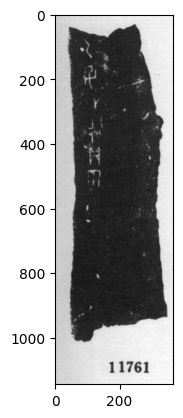

In [98]:
img = cv2.imread("visualization/raw_h11761.jpg")
plt.imshow(img)


True

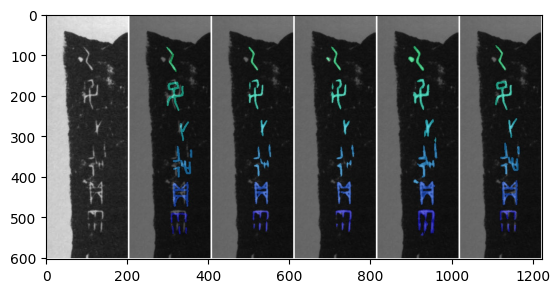

In [101]:
import matplotlib.pyplot as plt
import cv2
import os
folder = ['raw_', 'OBIMD_raw_hj', 'OBIMD_segformer', 'OBIMD_charformer', 'OBIMD_stage3_selfiter', 'OBIMD_iou0.6_stage4']
imgs = []
box = [0, 0, 200, 600]
for f in folder:
    img = cv2.imread(f"visualization/{f}h11761.jpg")
    img = img[box[1]:box[3], box[0]:box[2]]
    img = cv2.copyMakeBorder(
        img,
        top=2,
        bottom=2,
        left=2,
        right=2,
        borderType=cv2.BORDER_CONSTANT,  # 常量边框（颜色固定）
        value=(255, 255, 255)
    )
    imgs.append(img)
imgs = np.concatenate(imgs, axis=1)
plt.imshow(imgs)
cv2.imwrite("visualization/h11761.jpg", imgs)

## 临时代码

In [ ]:
import json
import os
import cv2
import numpy as np
from pycocotools import mask as maskUtils
from matplotlib import pyplot as plt
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import cv2
import numpy as np
import json
import os
import random

rub = cv2.imread("data/OBIMD_hd_test/rubbing/hd108_c1.jpg")
facs = cv2.imread("data/OBIMD_hd_test/facsimile_raw/hd108_c1.jpg")
with open("data/OBIMD_hd_test/facsimile_json/hd108_c1.json", 'r') as f:
    data = json.load(f)
boxes = []
for file in data['annotations']:
    x, y, w, h = file['crop_box']
    boxes.append([x, y, x+w, y+h])
boxes = np.array(boxes).reshape(-1, 4)
new_mask = np.zeros_like(rub)
np.random.seed(42)
for box in boxes:
    x1, y1, x2, y2 = box
    color = np.random.random(3) * 255
    new_mask[y1:y2, x1:x2] = (facs[y1:y2, x1:x2] > 127) * color
    cv2.rectangle(new_mask, (x1, y1), (x2, y2), color, 2)
    cv2.rectangle(rub, (x1, y1), (x2, y2), color, 2)
overlap = cv2.addWeighted(rub, 0.3, new_mask, 0.7, 0)
cv2.imwrite("overlap.jpg", overlap)

## grid采样

In [10]:
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
import cv2
import numpy as np
import json
import os
from tqdm import tqdm
from pycocotools import mask as maskUtils
import matplotlib.pyplot as plt
from sam2.data_utils.utils import calculate_mask_ap, get_tight_box

sam2_checkpoint = "sam2_logs/configs/sam2.1_iou_exp/iou0.6/sam2.1_hiera_l_OBIMD_stage4.yaml/checkpoints/checkpoint_5.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l_highres.yaml"
sam2_model = build_sam2(model_cfg, sam2_checkpoint, device='cuda:0')
x, y = np.meshgrid(np.linspace(0, 1, 32), np.linspace(0, 1, 32))
point_grids = np.stack([x, y], axis=-1).reshape(-1, 2)
mask_generator = SAM2AutomaticMaskGenerator(sam2_model, points_per_side=None, point_grids=[point_grids], pred_iou_thresh=0.5, stability_score_thresh=0.7, multimask_output=False, points_per_batch=8)
def show_anns_cv2(image, anns):
    if len(anns) == 0:
        return image
    
    img_with_mask = image.copy()
    H, W = img_with_mask.shape[:2]
    
    sorted_anns = sorted(anns, key=lambda x: x['area'], reverse=True)
    color_mask = np.zeros_like(image)
    for ann in sorted_anns:
        mask = ann['segmentation'].astype(np.uint8) * 255
        x, y, w, h = get_tight_box(mask)
        x0, y0, x1, y1 = int(x), int(y), int(x + w), int(y + h)
        image = cv2.rectangle(image, (x0, y0), (x1, y1), (0, 255, 0), 2)
        color = np.random.randint(0, 256, size=3).tolist()  # BGR随机色
        
        # color_layer = np.zeros_like(img_with_mask, dtype=np.uint8)
        # color_layer[:] = color  # 纯色层
        # roi = img_with_mask[mask > 0]  # 筛选mask区域的像素 (N, 3)
        # color_roi = np.tile(color, (roi.shape[0], 1))  # 生成与ROI同形状的颜色层 (N, 3)
        
        # # 半透明混合：(原图 * (1-alpha)) + (颜色层 * alpha)
        # mixed_roi = cv2.addWeighted(
        #     roi.astype(np.float32), 1 - alpha,
        #     color_roi.astype(np.float32), alpha,
        #     gamma=0
        # ).astype(np.uint8)  # 转回uint8格式
        
        # 赋值回原图（此时维度匹配：(N,3) -> (N,3)）
        color_mask[mask > 0] = color
    image = cv2.addWeighted(image.astype(np.float32), 0.5, color_mask.astype(np.float32), 0.5, 0)
    return image

In [11]:
miou = []
fscore = []
gt_coco_format = dict(info={}, license=[], categories=[dict(id=1, name="oracle")],
                      images=[], annotations=[])
pred_coco = []
for i, img_path in tqdm(enumerate(sorted(os.listdir('data/OBIMD_test100/rubbing')))):
    image = cv2.imread(os.path.join('data/OBIMD_test100/rubbing', img_path))
    H, W = image.shape[:2]
    gt_masks = cv2.imread(os.path.join('data/OBIMD_test100/facsimile', img_path), cv2.IMREAD_GRAYSCALE) / 255
    base_name = os.path.splitext(img_path)[0]
    gt_coco_format['images'].append(dict(id=i, file_name=img_path, height=H, width=W))

    with open(os.path.join('data/OBIMD_test100/facsimile_json', f'{base_name}.json')) as f:
        data = json.load(f)

    preds = mask_generator.generate(image)
    panoptic = show_anns_cv2(image, preds)
    cv2.imwrite(os.path.join('sam2_logs/configs/sam2.1_iou_exp/iou0.6/sam2.1_hiera_l_OBIMD_stage4.yaml/visualization_grid', img_path), panoptic)

    # 加载ground truth
    for d in data['annotations']:
        binary_mask = maskUtils.decode(d['segmentation'])
        d.update({"image_id": i, "category_id": 1, "iscrowd": 0})
        d['bbox'] = d['bbox']
        gt_coco_format['annotations'].append(d)


    # 统计instance segmentation指标
    for pred in preds:
        mask = np.asfortranarray(pred['segmentation'])
        rle = maskUtils.encode(mask)
        rle['counts'] = rle['counts'].decode('utf-8')
        pred_coco.append(dict(image_id=i,
                              category_id=1,
                              bbox=pred['bbox'], 
                              area=pred['area'], 
                              segmentation=rle, 
                              score=pred['predicted_iou'], 
                              crop_box=pred['crop_box']))
    
    # 计算语义分割指标   
    masks = np.stack([pred['segmentation'] for pred in preds]).any(axis=0)
    miou.append(np.sum(masks * gt_masks) / (np.sum(masks) + np.sum(gt_masks) - np.sum(masks * gt_masks)))
    precision = np.sum(masks * gt_masks) / np.sum(masks)
    recall = np.sum(masks * gt_masks) / np.sum(gt_masks)
    fscore.append(2 * precision * recall / (precision + recall + 1e-8))
print('miou', np.mean(miou), 'fscore', np.mean(fscore))
calculate_mask_ap(gt_coco_format, pred_coco)

0it [00:00, ?it/s]

100it [05:42,  3.42s/it]


miou 0.4943574253864773 fscore 0.6464501093193455
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=0.18s).
Accumulating evaluation results...
DONE (t=0.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.236
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.632
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.057
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.275
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.233
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.047
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.292
 Average Recal

{'mask_ap': 0.23648251819685098,
 'mask_ap50': 0.631619207906434,
 'mask_ap75': 0.05682360483720155,
 'mask_ap_small': 0.27476359486053076,
 'mask_ap_medium': 0.23274375790935747,
 'mask_ap_large': -1.0}

In [71]:
import os
import random
import cv2
import numpy as np
from matplotlib import pyplot as plt    
folder = ['data/OBIMD_test100/visualization', 'sam2_logs/configs/sam2.1_iou_exp/iou0.6/sam2.1_hiera_l_OBIMD_stage4.yaml/visualization_gt',
          'sam2_logs/configs/sam2.1_iou_exp/iou0.6/sam2.1_hiera_l_OBIMD_stage4.yaml/visualization_yolo', 'sam2_logs/configs/sam2.1_iou_exp/iou0.6/sam2.1_hiera_l_OBIMD_stage4.yaml/visualization_grid']
file = 'h21530.jpg' #random.choice(os.listdir(folder[0]))
imgs = [cv2.imread(os.path.join(f, file))[80:210, 110:270] for f in folder]
imgs = [cv2.copyMakeBorder(
        img,
        top=1,
        bottom=1,
        left=1,
        right=1,
        borderType=cv2.BORDER_CONSTANT,  # 常量边框（颜色固定）
        value=(255, 255, 255)
    ) for img in imgs]
imgs = np.concatenate(imgs, axis=1)

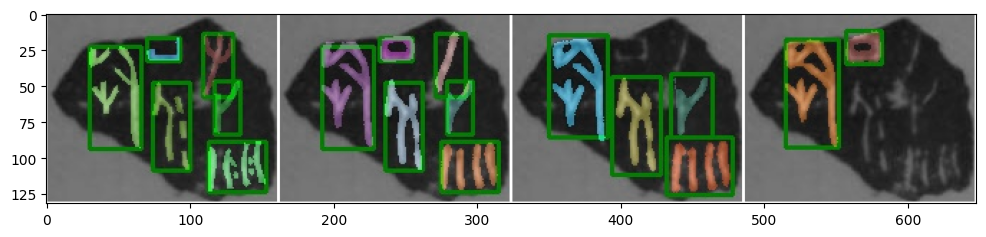

In [72]:
plt.figure(figsize=(12, 12))
plt.imshow(imgs)

In [73]:
cv2.imwrite(file, imgs)


True